### Load packages

In [868]:
import pandas as pd
import numpy as np
import os

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib.transforms as transforms

import plotly.graph_objects as go
import plotly.io as pio
from PIL import Image

# For output to PDF
# from pathlib import Path
# from playwright.async_api import async_playwright

### Define parameters and file info

In [869]:
pd.set_option('display.max_colwidth', None)

In [870]:
data_directory = r"..\data\nonprofit_economy"

# -----------------------------------------------------------------------
# CSV data for network diagram
# -----------------------------------------------------------------------

node_file = r"MCN_nonprofit_economy_revenue_nodes_2023.csv"
node_path = os.path.join(data_directory, node_file)
print("Node CSV file:", node_path)
if os.path.exists(node_path):
    print("EXISTS")

edge_file = r"MCN_nonprofit_economy_revenue_edges_2023.csv"
edge_path = os.path.join(data_directory, edge_file)
print("Edge CSV file:", edge_path)
if os.path.exists(edge_path):
    print("EXISTS")

# -----------------------------------------------------------------------
# CSV data for bar graphs
# -----------------------------------------------------------------------

asset_file = r"MCN_nonprofit_economy_assets_bar_2023.csv"
asset_path = os.path.join(data_directory, asset_file)
print("Assets CSV file:", asset_path)
if os.path.exists(asset_path):
    print("EXISTS")

rev_file = r"MCN_nonprofit_economy_revenue_bar_2023.csv"
rev_path = os.path.join(data_directory, rev_file)
print("Revenue CSV file:", rev_path)
if os.path.exists(rev_path):
    print("EXISTS")

# -----------------------------------------------------------------------
# Output
# -----------------------------------------------------------------------

output_directory = r"..\figures"

network_html_no_bars_output_file = "MCN_nonprofit_economy_sankey_no_bars_2023"
network_html_with_bars_output_file = "MCN_nonprofit_economy_sankey_with_bars_2023"

# Output path for combined figure with bars
network_html_with_bars_output_path = os.path.join(
    output_directory,
    network_html_with_bars_output_file + ".html"
)

# Output path for figure without bars
network_html_no_bars_output_path = os.path.join(
    output_directory,
    network_html_no_bars_output_file + ".html"
)

Node CSV file: ..\data\nonprofit_economy\MCN_nonprofit_economy_revenue_nodes_2023.csv
EXISTS
Edge CSV file: ..\data\nonprofit_economy\MCN_nonprofit_economy_revenue_edges_2023.csv
EXISTS
Assets CSV file: ..\data\nonprofit_economy\MCN_nonprofit_economy_assets_bar_2023.csv
EXISTS
Revenue CSV file: ..\data\nonprofit_economy\MCN_nonprofit_economy_revenue_bar_2023.csv
EXISTS


### Define functions

In [871]:
# Define function to save figure

def save_figure(fig, filename, dpi=300):

    output_path = os.path.join(output_directory, filename + ".png")

    fig.savefig(
        # filename,
        output_path,
        dpi=dpi,
        bbox_inches="tight",
        pad_inches=0.01
    )

### Load data

In [872]:
# Load nonprofit economy node data

node_raw_df = pd.read_csv(node_path)
node_raw_df.head()

,Node,Node Type,X,Y,X Offset,Y Offset
0,Donor-advised fund sponsors,Intermediary Right,0.600,0.0400,0.032,-0.007
1,Donor-advised fund sponsors (ghost),Ghost,0.630,0.0375,0.000,0.000
2,Foundations (minus community foundation DAF sponsors),Intermediary Right,0.330,0.0800,0.025,-0.010
3,Foundations (minus community foundation DAF sponsors) (ghost),Ghost,0.355,0.0745,0.000,0.000
4,Program fees from private sources,Source,0.100,0.8600,0.020,-0.037


In [873]:
# Load nonprofit economy edge data

edge_raw_df = pd.read_csv(edge_path)
edge_raw_df.head()

,Source,Recipient,Amount
0,Donor-advised fund sponsors,"Arts, culture, humanities",2.68
1,Donor-advised fund sponsors,Education (minus colleges and universities),6.48
2,Donor-advised fund sponsors,Colleges and universities,5.26
3,Donor-advised fund sponsors,Environment and animals,2.55
4,Donor-advised fund sponsors,Health (minus hospitals and nursing homes),2.92


In [874]:
# Load nonprofit economy asset bar graph data

asset_raw_df = pd.read_csv(asset_path)
asset_raw_df.head()

,Activity Area Original,Activity Area,Total
0,"Arts, Culture, Humanities",Arts & culture,1.870000e+11
1,Education,Other education,6.290000e+11
2,Colleges and Universities,Colleges/universities,9.500000e+11
3,Environment and Animals,Environment/animals,7.894316e+10
4,Health,Other healthcare,5.440000e+11


In [875]:
# Load nonprofit economy revenue bar graph data

revenue_raw_df = pd.read_csv(rev_path)
revenue_raw_df.head()

,Activity Area Original,Activity Area,Year,Revenue Adjusted for Inflation
0,Hospitals and nursing homes,Hospitals/nursing homes,2006,895
1,Hospitals and nursing homes,Hospitals/nursing homes,2009,896
2,Hospitals and nursing homes,Hospitals/nursing homes,2015,"1,239"
3,Hospitals and nursing homes,Hospitals/nursing homes,2023,"1,296"
4,Higher Education,Colleges/universities,2006,242


### Clean up data in network diagram dataframes

In [876]:
# Clean & format columns in edge data

edge_clean_df = edge_raw_df.copy()

edge_clean_df["Amount"] = pd.to_numeric(
    edge_clean_df["Amount"]
        .replace("-", 0)
        .str.replace(",", "", regex=False),
    errors="coerce"
)

print(len(edge_clean_df))
edge_clean_df.head()

132


,Source,Recipient,Amount
0,Donor-advised fund sponsors,"Arts, culture, humanities",2.68
1,Donor-advised fund sponsors,Education (minus colleges and universities),6.48
2,Donor-advised fund sponsors,Colleges and universities,5.26
3,Donor-advised fund sponsors,Environment and animals,2.55
4,Donor-advised fund sponsors,Health (minus hospitals and nursing homes),2.92


In [877]:
edge_clean_df[edge_clean_df["Source"].str.contains("Program")].head(10)

,Source,Recipient,Amount
106,Program fees from private sources,"Arts, culture, humanities",14.70
107,Program fees from private sources,Education (minus colleges and universities),78.61
108,Program fees from private sources,Colleges and universities,194.10
109,Program fees from private sources,Environment and animals,7.30
110,Program fees from private sources,Health (minus hospitals and nursing homes),219.66
111,Program fees from private sources,Hospitals and nursing homes,1207.49
112,Program fees from private sources,Human Services,148.38
113,Program fees from private sources,International/foreign affairs,3.26
114,Program fees from private sources,Public/societal benefit (minus national DAF sponsors),34.56
115,Program fees from private sources,Foundations (minus community foundation DAF sponsors),1.03


In [878]:
node_raw_df.head()

,Node,Node Type,X,Y,X Offset,Y Offset
0,Donor-advised fund sponsors,Intermediary Right,0.600,0.0400,0.032,-0.007
1,Donor-advised fund sponsors (ghost),Ghost,0.630,0.0375,0.000,0.000
2,Foundations (minus community foundation DAF sponsors),Intermediary Right,0.330,0.0800,0.025,-0.010
3,Foundations (minus community foundation DAF sponsors) (ghost),Ghost,0.355,0.0745,0.000,0.000
4,Program fees from private sources,Source,0.100,0.8600,0.020,-0.037


In [879]:
# Function for setting node totals

def get_total(row):
    node = row["Node"]
    node_type = row["Node Type"]

    if node_type == "Source":
        amount = edge_clean_df.loc[
            edge_clean_df["Source"] == node,
            "Amount"
        ].sum()

        return f"${amount:,.0f}B"

    elif node_type == "Recipient":
        amount = edge_clean_df.loc[
            edge_clean_df["Recipient"] == node,
            "Amount"
        ].sum()

        return f"${amount:,.0f}B"

    elif node_type == "Intermediary Right":
        incoming = edge_clean_df.loc[
            edge_clean_df["Recipient"] == node,
            "Amount"
        ].sum()

        outgoing = edge_clean_df.loc[
            edge_clean_df["Source"] == node,
            "Amount"
        ].sum()

        return f"In: ${incoming:,.0f}B<br>Out: ${outgoing:,.0f}B"

    return ""

In [880]:
# Add column for total in or out of node

node_totals_df = node_raw_df.copy()

node_totals_df["Total"] = node_totals_df.apply(get_total, axis=1)

node_totals_df.head(10)

,Node,Node Type,X,Y,X Offset,Y Offset,Total
0,Donor-advised fund sponsors,Intermediary Right,0.600,0.0400,0.032,-0.0070,In: $64B<br>Out: $54B
1,Donor-advised fund sponsors (ghost),Ghost,0.630,0.0375,0.000,0.0000,
2,Foundations (minus community foundation DAF sponsors),Intermediary Right,0.330,0.0800,0.025,-0.0100,In: $146B<br>Out: $91B
3,Foundations (minus community foundation DAF sponsors) (ghost),Ghost,0.355,0.0745,0.000,0.0000,
4,Program fees from private sources,Source,0.100,0.8600,0.020,-0.0370,"$1,923B"
5,Federal government,Source,0.100,0.7700,0.020,-0.0250,$309B
6,State and local government,Source,0.100,0.6800,0.020,-0.0280,$168B
7,Federated Giving,Source,0.100,0.5900,0.020,-0.0012,$3B
8,Investment Income,Source,0.100,0.5000,0.020,-0.0005,$67B
9,Corporations,Source,0.100,0.4100,0.020,0.0010,$37B


In [881]:
# Function to find the middle of a string and add a <br> at the space that is closest to that wrap_at_middle

def wrap_at_middle(text):
    if pd.isna(text):
        return text
    
    # Find positions of all spaces
    space_positions = [i for i, char in enumerate(text) if char == " "]
    
    # If no spaces, return unchanged
    if not space_positions:
        return text
    
    # Midpoint of string
    midpoint = len(text) / 2
    
    # Find space closest to midpoint
    split_pos = min(space_positions, key=lambda x: abs(x - midpoint))
    
    # Insert <br>
    if "DAF" in text:
        wrapped_text = text
    else:
        wrapped_text = text[:split_pos] + "<br>" + text[split_pos + 1:]

    return wrapped_text

In [882]:
# add extra columns for node name formatting
node_colname_df = node_totals_df.copy()

node_colname_df["Node Short"] = node_colname_df["Node"].replace({
    "Donor-advised fund sponsors": "DAF sponsors",
    "Donor-advised fund sponsors (ghost)": "DAF sponsors (ghost)",
    "Foundations (minus community foundation DAF sponsors)": "Foundations",
    "Foundations (minus community foundation DAF sponsors) (ghost)": "Foundations (ghost)",
    "Program fees from private sources": "Program fees",
    "State and local government": "State & local government",
    "Federated Giving": "Federated giving",
    "Hospitals and nursing homes": "Hospitals & nursing homes",
    "Health (minus hospitals and nursing homes)": "Other healthcare",
    "Education (minus colleges and universities)": "Other education",
    "Public/societal benefit (minus national DAF sponsors)": "Public/societal benefit",
    "Arts, culture, humanities": "Arts & culture",
    "Environment and animals": "Environment & animals",
    "International/foreign affairs": "International/ foreign affairs",
    "Unknown, unclassified": "Other"
})

In [883]:
# Create a different node text columns for different needs

node_format_df = node_colname_df.copy()

# Create Node Wrapped column
node_format_df["Node Wrapped"] = node_format_df["Node Short"].apply(wrap_at_middle)

# Create Node Hover column
node_format_df["Node Hover"] = node_format_df["Node Short"].str.replace(" (ghost)", "", regex=False)

# Create Node Totals column

conditions = [
    node_format_df["Node Type"] == "Source",
    node_format_df["Node Type"] == "Recipient",
    node_format_df["Node Type"].isin(["Intermediary Right", "Intermediary Left"])
]

choices = [
    # "From<br>" + node_format_df["Node Wrapped"] + "<br>" + node_format_df["Total"].astype(str),
    "From<br>" + (node_format_df["Node Wrapped"].str[:1].str.lower() + node_format_df["Node Wrapped"].str[1:]) + "<br>" + node_format_df["Total"].astype(str),
    # "To<br>" + node_format_df["Node Wrapped"] + "<br>" + node_format_df["Total"].astype(str),
    "To<br>" + (node_format_df["Node Wrapped"].str[:1].str.lower() + node_format_df["Node Wrapped"].str[1:]) + "<br>" + node_format_df["Total"].astype(str),
    
    node_format_df["Node Wrapped"] + "<br>" + node_format_df["Total"].astype(str)
]

node_format_df["Node Totals"] = np.select(
    conditions,
    choices,
    default=node_format_df["Node Wrapped"]
)

node_format_df.head(20)

,Node,Node Type,X,Y,X Offset,Y Offset,Total,Node Short,Node Wrapped,Node Hover,Node Totals
0,Donor-advised fund sponsors,Intermediary Right,0.600,0.0400,0.032,-0.0070,In: $64B<br>Out: $54B,DAF sponsors,DAF sponsors,DAF sponsors,DAF sponsors<br>In: $64B<br>Out: $54B
1,Donor-advised fund sponsors (ghost),Ghost,0.630,0.0375,0.000,0.0000,,DAF sponsors (ghost),DAF sponsors (ghost),DAF sponsors,DAF sponsors (ghost)
2,Foundations (minus community foundation DAF sponsors),Intermediary Right,0.330,0.0800,0.025,-0.0100,In: $146B<br>Out: $91B,Foundations,Foundations,Foundations,Foundations<br>In: $146B<br>Out: $91B
3,Foundations (minus community foundation DAF sponsors) (ghost),Ghost,0.355,0.0745,0.000,0.0000,,Foundations (ghost),Foundations<br>(ghost),Foundations,Foundations<br>(ghost)
4,Program fees from private sources,Source,0.100,0.8600,0.020,-0.0370,"$1,923B",Program fees,Program<br>fees,Program fees,"From<br>program<br>fees<br>$1,923B"
5,Federal government,Source,0.100,0.7700,0.020,-0.0250,$309B,Federal government,Federal<br>government,Federal government,From<br>federal<br>government<br>$309B
6,State and local government,Source,0.100,0.6800,0.020,-0.0280,$168B,State & local government,State & local<br>government,State & local government,From<br>state & local<br>government<br>$168B
7,Federated Giving,Source,0.100,0.5900,0.020,-0.0012,$3B,Federated giving,Federated<br>giving,Federated giving,From<br>federated<br>giving<br>$3B
8,Investment Income,Source,0.100,0.5000,0.020,-0.0005,$67B,Investment Income,Investment<br>Income,Investment Income,From<br>investment<br>Income<br>$67B
9,Corporations,Source,0.100,0.4100,0.020,0.0010,$37B,Corporations,Corporations,Corporations,From<br>corporations<br>$37B


### Prepare data for plotting

In [884]:
# Select node field to use

node_display_field = "Node Totals"
node_id_field = "Node"

In [885]:
# Remove the DAF-to-foundation edge amount (we're showing that total in the foundation-to-daf hover text instead)

edge_deduped_df = edge_clean_df.copy()

dupe_edge_mask = (
    (edge_deduped_df["Source"].str.contains("Donor-advised", na=False)) & 
    (edge_deduped_df["Recipient"].str.contains("Foundations", na=False))
)

edge_deduped_df.loc[dupe_edge_mask, "Amount"] = 0

edge_deduped_df.head(10)

,Source,Recipient,Amount
0,Donor-advised fund sponsors,"Arts, culture, humanities",2.68
1,Donor-advised fund sponsors,Education (minus colleges and universities),6.48
2,Donor-advised fund sponsors,Colleges and universities,5.26
3,Donor-advised fund sponsors,Environment and animals,2.55
4,Donor-advised fund sponsors,Health (minus hospitals and nursing homes),2.92
5,Donor-advised fund sponsors,Hospitals and nursing homes,2.10
6,Donor-advised fund sponsors,Human Services,7.76
7,Donor-advised fund sponsors,International/foreign affairs,2.55
8,Donor-advised fund sponsors,Public/societal benefit (minus national DAF sponsors),8.88
9,Donor-advised fund sponsors,Foundations (minus community foundation DAF sponsors),0.00


In [886]:
# Prepare data for plotting

# Build a node map (convert node labels into integer indices)
node_map = {
    node: i for i, node in enumerate(node_format_df[node_id_field])
}

# Convert source and recipient node into indices
sources = edge_deduped_df["Source"].map(node_map)
targets = edge_deduped_df["Recipient"].map(node_map)
values = edge_deduped_df["Amount"]

### Color and font settings

In [887]:
# Color settings

custom_alpha = 0.35

# Bar graph colors
network_blue = "#6EAAE6"
network_gray = "#898989"
background_color = "#F5F5F5"
spine_color = "#BDBDBD"

# Intermediary colors
daf_color = "#962F3F"
pf_color = "#244477"

recipient_node_color = "#B4B4B4"
node_outline_color = "#666666"

# Funding source colors
source_colors = [
    "#A0A0A0",  # gray
    "#E66E6E",  # pink
    "#E6AA6E",  # orange
    "#E6D26E",  # yellow
    "#A0CD78",  # green
    "#78BEAA",  # teal
    "#6EAAE6",  # blue
    "#AA6EE6",  # purple
]

category_palette_index = {
    "Program fees from private sources": 0,
    "Federal government": 1,
    "State and local government": 2,
    "Federated Giving": 3,
    "Investment Income": 4,
    "Corporations": 5,
    "Bequests": 6,
    "Individuals": 7,
}

# Font settings

# Font sizes for figures for bar graphs
bar_axis_titlesize = 12
bar_axis_labelsize = 9
bar_facet_titlesize = 9
bar_caption_size = 8
# Font sizes for figures for paper
axis_titlesize = 18
axis_labelsize = 14
facet_titlesize = 14
caption_size = 10
# Font sizes for figures for powerpoint
ppt_axis_titlesize = 14
ppt_axis_labelsize = 14
ppt_facet_titlesize = 16
ppt_caption_size = 12
ppt_titlesize = 20

# GLOBAL DEFAULT SEABORN STYLE SETTINGS

sns.set(
    style="whitegrid",
    rc={
        "axes.labelsize": axis_labelsize,
        "xtick.labelsize": axis_labelsize,
        "ytick.labelsize": axis_labelsize,
    }
)

In [888]:
# Function to turn colors into RGBA values so I can use my alpha values
def to_rgba(hex_color, alpha=custom_alpha):
    hex_color = hex_color.lstrip("#")
    r = int(hex_color[0:2], 16)
    g = int(hex_color[2:4], 16)
    b = int(hex_color[4:6], 16)
    return f"rgba({r},{g},{b},{alpha})"

In [889]:
# Function to map a color to the right edge or node by index
def get_color(node):
    if "Donor-advised fund" in node:
        return to_rgba(daf_color)

    if "Foundations" in node:
        return to_rgba(pf_color)

    idx = category_palette_index.get(node, 0)
    return to_rgba(source_colors[idx])

In [890]:
print(edge_raw_df["Source"].isna().sum())
print(edge_raw_df["Source"].value_counts(dropna=False))

0
Source
Donor-advised fund sponsors                                      13
Individuals                                                      13
Foundations (minus community foundation DAF sponsors)            13
Bequests                                                         13
Program fees from private sources                                13
Federated Giving                                                 13
Corporations                                                     13
State and local government                                       13
Investment Income                                                13
Federal government                                               13
Donor-advised fund sponsors (ghost)                               1
Foundations (minus community foundation DAF sponsors) (ghost)     1
Name: count, dtype: int64


In [891]:
# Map colors to edges and nodes

edge_colors = edge_deduped_df["Source"].map(get_color)

node_colors = node_format_df["Node"].apply(get_color)

# Set all recipient nodes to medium gray
node_colors[node_format_df["Node Type"] == "Recipient"] = recipient_node_color

### Prepare node and hover text

In [892]:
# Set font family

# font_family = "Source Sans 3, Helvetica Neue, Arial, sans-serif"
# font_family = "Inter, Segoe UI, Roboto, Arial, sans-serif"
font_family = "Arial, Helvetica, sans-serif"

# Build a CSS-safe version of the font_family variable

font_family_css = ", ".join(
    f'"{f.strip()}"' if " " in f.strip() else f.strip()
    for f in font_family.split(",")
)

In [893]:
# Create custom node names 
# node_names = node_format_df[node_display_field].tolist()
hover_node_names = node_format_df["Node Hover"].tolist()

# Build hover display fields
hover_text = []

for s, t, v in zip(sources, targets, values):
    source_name = hover_node_names[s]
    target_name = hover_node_names[t]

    if "DAF" in target_name:
        hover_target_name = target_name
    else:
        hover_target_name = target_name[0].lower() + target_name[1:] # lowercase first letter in target name

    if ("Foundations" in source_name) & ("DAF" in target_name):
        # Special custom text for DAf-to-Foundations backwards giving
        hover_text.append(
            f'<div style="font-size: 12px; margin: 0;">'
            f'{source_name} to</br>{hover_target_name}'
            f'</div>'
            f'<div style="font-size: 16px; margin-top: 4px;">'
            f'<b>${v:,.1f}B</b>'
            f'</div>'
            f'<br>{hover_target_name} to</br>{source_name}'
            f'</div>'
            f'<div style="font-size: 16px; margin-top: 4px;">'
            f'<b>${3.12:,.1f}B</b>'
            f'</div>'
        )
    else:
        hover_text.append(
            f'<div style="font-size: 12px; margin: 0;">'
            f'{source_name} to</br>{hover_target_name}'
            f'</div>'
            f'<div style="font-size: 16px; margin-top: 4px;">'
            f'<b>${v:,.1f}B</b>'
            f'</div>'
        )

### Visualize with Plotly Sankey (static charts)

Using Plotly Sankey because it includes the best compromises for:
- weighted edges
- self-loops (still poor)
- curved edges
- label control (still poor)
- heirarchy levels
- interactivity
- quality
- merging flows

In [894]:
# Plot the diagram
network_fig = go.Figure(go.Sankey(
    arrangement="snap",
    
    node=dict(
        # label=node_format_df["Node"],
        label=[""] * len(node_format_df), # remove default labels
        x=node_format_df["X"],
        y=node_format_df["Y"],
        pad=15,
        thickness=18,
        line=dict(color=to_rgba("#454545", alpha=0.5), width=0.25),
        # line=dict(color="rgba(0,0,0,0)", width=0),
        color=node_colors,
        hoverinfo="skip"
    ),
    
    link=dict(
        # arrowlen=10,
        source=sources,
        target=targets,
        value=values,
        color=edge_colors,
        customdata=hover_text,
        hoverinfo="none"
        # hovertemplate="%{customdata}<extra></extra>"
    )
))

# Define annotations for labels
annotations = []

for _, row in node_format_df[node_format_df["Node Type"] == "Source"].iterrows():
    node_name = row[node_id_field]
    dx = row["X Offset"]
    dy = row["Y Offset"]
    annotations.append(dict(
        x=row["X"] - dx,
        y=(1 - row["Y"]) + dy,
        text=row[node_display_field],
        showarrow=False,
        xanchor="right",
        align="center",
        textangle=-90
    ))

for _, row in node_format_df[node_format_df["Node Type"] == "Recipient"].iterrows():
    dx = row["X Offset"]
    dy = row["Y Offset"]
    annotations.append(dict(
        x=row["X"] + dx,
        y=(1 - row["Y"]) + dy,
        text=row[node_display_field],
        showarrow=False,
        xanchor="left",
        align="center",
        textangle=-90
    ))
for _, row in node_format_df[node_format_df["Node Type"] == "Intermediary Left"].iterrows():
    dx = row["X Offset"]
    dy = row["Y Offset"]
    annotations.append(dict(
        x=row["X"] - dx,
        y=(1 - row["Y"]) + dy,
        text=row[node_display_field],
        showarrow=False,
        xanchor="left",
        align="left",
        textangle=-90
    ))

for _, row in node_format_df[node_format_df["Node Type"] == "Intermediary Right"].iterrows():
    dx = row["X Offset"]
    dy = row["Y Offset"]
    annotations.append(dict(
        x=row["X"] + dx,
        y=(1 - row["Y"]) + dy,
        text=row[node_display_field],
        showarrow=False,
        xanchor="right",
        align="right",
        textangle=-90
    ))

# Format
network_fig.update_layout(
    # title_text="Nonprofit Economy Flows (2023)",
    font_size=10,
    width=800,
    height=1100,
    margin=dict(l=20, r=20, t=40, b=20),
    font=dict(family=font_family, size=11, color="black"),
    annotations=annotations
)

network_fig.show()

### Output image

In [895]:

# Output as PNG
# fig_png_output_path = os.path.join(output_directory, network_html_no_bars_output_file + ".png")
# fig.write_image(fig_png_output_path)

# Output as SVG
# fig_svg_output_path = os.path.join(output_directory, network_html_no_bars_output_file + ".svg")
# fig.write_image(fig_svg_output_path)

In [896]:
# Output to HTML

# fig_html_output_path = os.path.join(output_directory, network_html_no_bars_output_file + ".html")

# export as internet-required html page
# html_fragment = pio.to_html(fig, full_html=False, include_plotlyjs="cdn")

# export as fully standalone, no-internet-required html page
html_fragment = pio.to_html(network_fig, full_html=False, include_plotlyjs=True)

full_html = f"""
<html>
<head>
<meta charset="utf-8" />
<style>
.rotated-wrapper {{
    position: relative;
    width: 1200px;
    height: 800px;
}}

.rotated-plot {{
    position: absolute;
    top: 0;
    left: 0;
    transform: rotate(90deg) translateY(-100%) translateX(0px);
    transform-origin: top left;
}}

#custom-tooltip {{
    font-family: {font_family_css};
    font-size: 8px;
    position: absolute;
    display: none;
    background: white;
    border: 1px solid #999;
    padding: 4px;
    font-size: 12px;
    pointer-events: none;
    z-index: 9999;
    box-shadow: 2px 2px 6px rgba(0,0,0,0.2);
}}

</style>
</head>
<body>

<div class="rotated-wrapper">
<div class="rotated-plot">
{html_fragment}
</div>
</div>

<div id="custom-tooltip"></div>

<script>
window.addEventListener("load", function() {{

    const tooltip = document.getElementById("custom-tooltip");
    const plotDiv = document.querySelector(".plotly-graph-div");

    if (!plotDiv) return;

    plotDiv.on("plotly_hover", function(eventData) {{

        const point = eventData.points[0];
        const e = eventData.event;

        tooltip.innerHTML = point.customdata;
        tooltip.style.display = "block";

        tooltip.style.left = (e.pageX + 15) + "px";
        tooltip.style.top = (e.pageY + 15) + "px";
    }});

    plotDiv.on("plotly_unhover", function() {{

        tooltip.style.display = "none";

    }});

}});
</script>

</body>
</html>
"""

with open(network_html_no_bars_output_path, "w", encoding="utf-8") as f:
    f.write(full_html)

### Bar graphs

In [897]:
# DATA: ASSETS

# fig_height = 1.3

# bar_font_family = ["Arial", "Source Sans 3", "Helvetica Neue", "sans-serif"]
bar_font_family = ["Arial", "sans-serif"]

# Safety copy of dataframe
asset_clean_df = asset_raw_df.copy()

# Rename columns
asset_clean_df.rename(
    columns={
        "Activity Area": "Activity Area",
        "Total": "Assets",
    },
    inplace=True
)

# Sort data
asset_clean_df = asset_clean_df.sort_values("Assets", ascending=False)

print(len(asset_clean_df))
asset_clean_df.head()

12


,Activity Area Original,Activity Area,Assets
5,Hospitals and Nursing Homes,Hospitals/nursing homes,1.780000e+12
2,Colleges and Universities,Colleges/universities,9.500000e+11
1,Education,Other education,6.290000e+11
8,"Public, Societal Benefit",Societal benefit,5.870000e+11
6,Human Services,Human services,5.440000e+11


[6.  1.4]


C:\Users\hefla\AppData\Local\Temp\ipykernel_40968\2476901.py:57: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



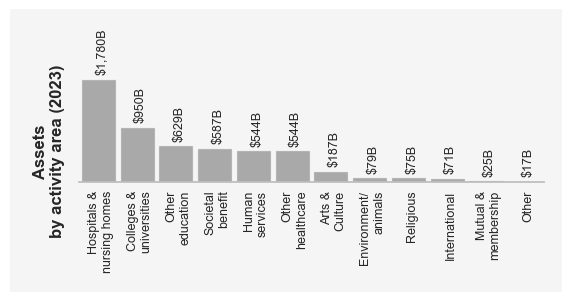

In [898]:
# FIGURE: ASSETS

fig, ax = plt.subplots(figsize=(6, 1.4))

plt.rcParams["font.family"] = bar_font_family

fig.patch.set_facecolor("white")
ax.set_facecolor(background_color)

# Rename some of the activity area descriptions to wrap
activity_area_labels = {
    "Hospitals/nursing homes": "Hospitals &\nnursing homes",
    "Colleges/universities": "Colleges &\nuniversities",
    "Other healthcare": "Other\nhealthcare",
    "Other education": "Other\neducation",
    "Human services": "Human\nservices",
    "Societal benefit": "Societal\nbenefit",
    "Religious congregations": "Religious",
    "Arts & culture": "Arts &\nCulture",
    "Environment/animals": "Environment/\nanimals",
    "Mutual/membership": "Mutual &\nmembership",
}

# Create barplot
sns.barplot(
    data=asset_clean_df,
    x="Activity Area",
    y="Assets",
    # color=network_blue,
    color=network_gray,
    alpha=0.7,
    dodge=False,
    width=0.9,
    legend=False,
    ax=ax
)

# Clean up spines and axes
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color(spine_color)
ax.grid(False)

ax.set_yticks([])
ax.set_xlabel("")
ax.set_ylabel("")

x_labels = [
    activity_area_labels.get(
        label.get_text(),
        label.get_text()
    )
    for label in ax.get_xticklabels()
]

ax.set_xticklabels(x_labels)

# Shift labels slightly to the left
label_shift = -0.05

ax.set_xticks(
    np.arange(len(x_labels)) + label_shift,
    labels=x_labels
)

# Format x-axis labels
ax.tick_params(
    axis="x",
    labelsize=bar_axis_labelsize,
    pad=0
)

plt.setp(
    ax.get_xticklabels(),
    rotation=-270,
    ha="right",
    va="top"
)

for label in ax.get_xticklabels():
    label.set_rotation_mode("anchor")

    if "\n" in label.get_text():
        label.set_transform(
            label.get_transform()
            + transforms.ScaledTranslation(
                -6 / 72,
                0,
                fig.dpi_scale_trans
            )
        )

# Add data labels on bars
data_label_padding = 0.1

for p in ax.patches:
    height = p.get_height()

    ax.text(
        p.get_x() + p.get_width() / 2 + data_label_padding,
        height + 70000000000,
        f"${height / 1000000000:,.0f}B",
        ha="center",
        va="bottom",
        fontsize=bar_axis_labelsize,
        rotation=90,
    )

# Determine label extent
fig.canvas.draw()

renderer = fig.canvas.get_renderer()

label_extents = [
    tick.label1.get_window_extent(renderer)
    for tick in ax.xaxis.get_major_ticks()
]

max_label_height = max(
    ext.height for ext in label_extents
)

# Convert from pixels to figure fraction
fig_height_pixels = fig.bbox.height

pos = ax.get_position()

pad_left = 0.115
pad_right = 0.03
pad_bottom = max_label_height / fig_height_pixels + 0.2
pad_top = 0.46

# Add light-gray panel
panel = Rectangle(
    (
        pos.x0 - pad_left,
        pos.y0 - pad_bottom
    ),
    pos.width + pad_left + pad_right,
    pos.height + pad_top + pad_bottom,
    facecolor=background_color,
    edgecolor="none",
    transform=fig.transFigure,
    zorder=0
)

fig.add_artist(panel)

# Make sure the graph is above the panel
ax.set_zorder(1)

# Add title
pos = ax.get_position()

title_pad = 0.065
fig.text(
    x=panel.get_x() + title_pad,
    y=panel.get_y() + panel.get_height() / 2,
    s="Assets\nby activity area (2023)",
    ha="center",
    va="center",
    fontsize=bar_axis_titlesize,
    fontweight="bold",
    rotation=90,
    zorder=2
)

print(fig.get_size_inches())

save_figure(
    fig,
    "assets_by_activity_area",
    dpi=300
)

plt.show()

In [899]:
# DATA: REVENUE

# Safety copy of dataframe
revenue_clean_df = revenue_raw_df.copy()

revenue_clean_df["Revenue Adjusted for Inflation"] = revenue_clean_df["Revenue Adjusted for Inflation"].str.replace(",", "").astype("Int64")
revenue_clean_df["Inflation-Adjusted Revenue in Billions"] = revenue_clean_df["Revenue Adjusted for Inflation"] * 1000000000
revenue_clean_df.head()

,Activity Area Original,Activity Area,Year,Revenue Adjusted for Inflation,Inflation-Adjusted Revenue in Billions
0,Hospitals and nursing homes,Hospitals/nursing homes,2006,895,895000000000
1,Hospitals and nursing homes,Hospitals/nursing homes,2009,896,896000000000
2,Hospitals and nursing homes,Hospitals/nursing homes,2015,1239,1239000000000
3,Hospitals and nursing homes,Hospitals/nursing homes,2023,1296,1296000000000
4,Higher Education,Colleges/universities,2006,242,242000000000


[10.   1.2]


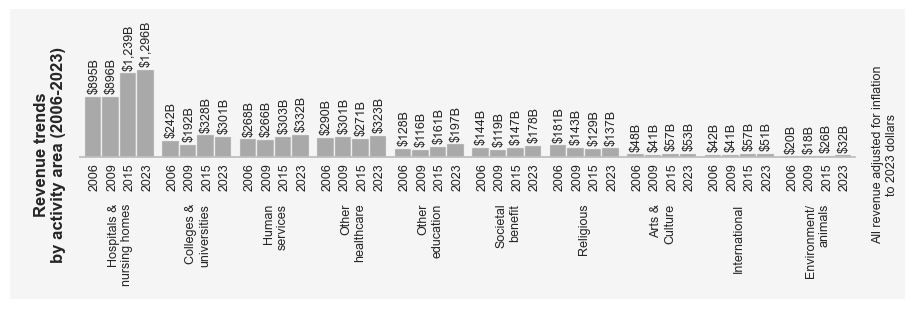

In [900]:
# FIGURE: REVENUE TRENDS

fig, ax = plt.subplots(figsize=(10, 1.2))

plt.rcParams["font.family"] = bar_font_family

fig.patch.set_facecolor("white")
ax.set_facecolor("#F5F5F5")

# Rename some of the activity area descriptions to wrap
activity_area_labels = {
    "Hospitals/nursing homes": "Hospitals &\nnursing homes",
    "Colleges/universities": "Colleges &\nuniversities",
    "Other healthcare": "Other\nhealthcare",
    "Other education": "Other\neducation",
    "Human services": "Human\nservices",
    "Societal benefit": "Societal\nbenefit",
    "Religious congregations": "Religious",
    "Arts & culture": "Arts &\nCulture",
    "Environment/animals": "Environment/\nanimals",
}

# Create barplot
sns.barplot(
    data=revenue_clean_df,
    x="Activity Area",
    y="Inflation-Adjusted Revenue in Billions",
    hue="Year",
    # palette=[network_blue] * revenue_clean_df["Year"].nunique(),
    palette=[network_gray] * revenue_clean_df["Year"].nunique(),
    alpha=0.7,
    dodge=True,
    width=0.9,
    legend=False,
    ax=ax
)

# Clean up spines and axes
ax.spines["bottom"].set_color(spine_color)
# ax.spines["bottom"].set_color("lightgray")
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.grid(False)

ax.set_yticks([])
ax.set_xlabel("")
ax.set_ylabel("")

# Get years and activity areas in plotting order
years = sorted(revenue_clean_df["Year"].unique())
activity_areas = list(revenue_clean_df["Activity Area"].unique())

# Remove the normal x-axis tick labels
ax.set_xticks([])

# Two-level x-axis labels
 
# Add year labels underneath each individual bar
nudge_year_labels = 0.03
for p, year in zip(ax.patches, np.repeat(years, len(activity_areas))):

    x = p.get_x() + p.get_width() / 2 + nudge_year_labels

    ax.text(
        x,
        -0.06,
        str(year),
        transform=ax.get_xaxis_transform(),
        ha="center",
        va="top",
        fontsize=bar_axis_labelsize,
        rotation=90
    )

# Add activity-area labels underneath each group of bars
pad_down_from_year_labels = -0.5
for i, activity_area in enumerate(activity_areas):

    label = activity_area_labels.get(
        activity_area,
        activity_area
    )

    if "\n" in label:
        nudge_right = 0.19
    else:
        nudge_right = 0.08

    ax.text(
        i + nudge_right,
        pad_down_from_year_labels,
        label,
        transform=ax.get_xaxis_transform(),
        ha="right",
        va="top",
        fontsize=bar_axis_labelsize,
        rotation=90
    )

# Add data labels on bars
data_label_padding = 0.025
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2 + data_label_padding,
        height + 40000000000,
        f"${height / 1000000000:,.0f}B",
        ha="center",
        va="bottom",
        fontsize=bar_axis_labelsize,
        rotation=90
    )

# Add outlines
fig.canvas.draw()

# Convert from pixels to figure fraction
fig_height_pixels = fig.bbox.height

pos = ax.get_position()
pad_left = 0.07
pad_right = 0.05
pad_bottom = max_label_height / fig_height_pixels + 0.5
pad_top = 0.46

rect = Rectangle(
    (pos.x0 - pad_left, pos.y0 - pad_bottom),
    pos.width + pad_left + pad_right,
    pos.height + pad_top + pad_bottom,
    # fill=False,
    # linewidth=0.75,
    facecolor="#F5F5F5",
    edgecolor="none",
    # edgecolor="darkgrey",
    transform=fig.transFigure,
    # zorder=0
)
fig.add_artist(rect)

# Make sure the graph is above the panel
ax.set_zorder(1)

# Add title 

title_pad = 0.04  # distance from left side of rectangle (figure fraction units)
fig.text(
    x=rect.get_x() + title_pad, # a little to the right
    y=rect.get_y() + rect.get_height()/2, # center vertically
    s="Revenue trends\nby activity area (2006-2023)",
    ha="center",
    va="center",
    fontsize=bar_axis_titlesize,
    fontweight="bold",
    rotation=90
)

# Add caption

caption_pad = 0.02

fig.text(
    x=rect.get_x() + rect.get_width() - caption_pad,
    y=rect.get_y() + rect.get_height() / 2,
    s="All revenue adjusted for inflation\nto 2023 dollars",
    ha="center",
    va="center",
    fontsize=bar_axis_labelsize,
    rotation=90
)

# Save figure 

print(fig.get_size_inches())
save_figure(fig, "revenue_trends_by_activity_area", dpi=300)
plt.show()

In [901]:
assets_img = Image.open(
    os.path.join(
        output_directory,
        "assets_by_activity_area.png"
    )
)

revenue_img = Image.open(
    os.path.join(
        output_directory,
        "revenue_trends_by_activity_area.png"
    )
)

print("Graph 2:", assets_img.size)
print("Graph 3:", revenue_img.size)

Graph 2: (1662, 853)
Graph 3: (2691, 875)


### <b>Create all-in-one graph from the sankey plus bar charts</b>

In [902]:
# ============================================================
# MASTER HTML: COMBINE ALL THREE FIGURES
# ============================================================

# Paths to the two static figures
assets_image_path = os.path.join(
    output_directory,
    "assets_by_activity_area.png"
)

revenue_image_path = os.path.join(
    output_directory,
    "revenue_trends_by_activity_area.png"
)

# ------------------------------------------------------------
# Read the two PNGs and convert them to base64 so that the
# resulting HTML is completely self-contained.
# ------------------------------------------------------------

import base64

def image_to_base64(image_path):
    with open(image_path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")

assets_base64 = image_to_base64(assets_image_path)
revenue_base64 = image_to_base64(revenue_image_path)


# ------------------------------------------------------------
# Get the Plotly HTML fragment from Graph 1
# ------------------------------------------------------------

html_fragment = pio.to_html(
    network_fig,
    full_html=False,
    include_plotlyjs=True
)


# ------------------------------------------------------------
# Build the complete HTML document
# ------------------------------------------------------------

full_html = f"""
<html>

<head>

<meta charset="utf-8" />

<style>

html,
body {{
    margin: 0;
    padding: 0;
    background: white;
}}


/* ----------------------------------------------------------
   OUTER CONTAINER

   This is the space occupied by the final rotated figure.
   ---------------------------------------------------------- */

.composite-wrapper {{
    position: relative;

    width: 1500px;
    height: 1500px;

    overflow: visible;
}}


/* ----------------------------------------------------------
   COMPOSITE GRID

   BEFORE rotation:

       ┌────────────────────────────────┐
       │        │                       │
       │ Graph 2│       Graph 3         │
       │        │                       │
       ├────────┴───────────────────────┤
       │                                │
       │             Graph 1            │
       │                                │
       └────────────────────────────────┘

   Then the ENTIRE grid is rotated 90 degrees.
   ---------------------------------------------------------- */

.composite {{
    position: absolute;

    top: 0;
    left: 0;

    width: 1100px;
    height: 1700px;

    display: grid;

    /* grid-template-columns: 345px 455px; */
    /* grid-template-rows: 250px 1100px; */

    grid-template-columns: 800px;
    grid-template-rows: 248px 20px 248px 1130px;

    gap: 0;

    transform: rotate(90deg) translateY(-100%);
    transform-origin: top left;

}}


/* ----------------------------------------------------------
   GRAPH 2
   ---------------------------------------------------------- */

.graph2 {{
    grid-column: 1;
    grid-row: 1;

    position: relative;
    overflow: hidden;

    display: flex;
    align-items: center;
    justify-content: flex-start;

    transform: translateX(25px);
}}

.graph2 img {{
    max-width: 100%;
    max-height: 100%;
    width: auto;
    height: auto;
    object-fit: contain;
}}

/* ----------------------------------------------------------
   GRAPH 3
   ---------------------------------------------------------- */

.graph3 {{
    grid-column: 1;
    /* grid-row: 1; */
    grid-row: 3;

    position: relative;
    overflow: hidden;

    display: flex;
    align-items: center;
    justify-content: flex-start;

    transform: translateX(25px);
}}

.graph3 img {{
    max-width: 100%;
    max-height: 100%;
    width: auto;
    height: auto;
    object-fit: contain;
}}

/* ----------------------------------------------------------
   GRAPH 1
   ---------------------------------------------------------- */

.graph1 {{
    /* grid-column: 1 / 3; */
    /* grid-row: 2; */
    grid-column: 1;
    grid-row: 4;

    position: relative;
    overflow: hidden;

    display: flex;
    justify-content: flex-start;
    align-items: center;

}}

/* ----------------------------------------------------------
   STATIC FIGURES
   ---------------------------------------------------------- */

.static-figure {{
    display: block;

    width: 100%;
    height: 100%;

    object-fit: contain;
}}


/* ----------------------------------------------------------
   CUSTOM PLOTLY TOOLTIP
   ---------------------------------------------------------- */

#custom-tooltip {{
    font-family: {font_family_css};

    font-size: 12px;

    position: fixed;

    display: none;

    background: white;

    border: 1px solid #999;

    padding: 4px;

    pointer-events: none;

    z-index: 9999;

    box-shadow: 2px 2px 6px rgba(0,0,0,0.2);
}}

/* ==========================================================
   PRINT / PDF EXPORT
   ========================================================== */

@media print {{

    @page {{
        size: 17in 11in landscape;
        margin: 0;
    }}

    html,
    body {{
        width: 17in;
        height: 11in;
        margin: 0;
        padding: 0;
        overflow: hidden;
        background: white;
    }}

    .composite-wrapper {{
        width: 17in;
        height: 11in;
        position: relative;
        overflow: hidden;
    }}

    .composite {{
        width: 9in;
        height: 11in;

        /* Move the entire composite image down a certain percentage from the top */
        top: 13%;
        left: 0px;

        transform: rotate(90deg) translateY(-150.5%) scale(0.96);
        transform-origin: top left;

        margin-top: 0;
    }}

    /* Don't let the browser add any surprises */
    * {{
        -webkit-print-color-adjust: exact !important;
        print-color-adjust: exact !important;
    }}

}}

</style>

</head>


<body>


<div class="composite-wrapper">

    <div class="composite">


        <!-- ================================================
             GRAPH 2 — ASSETS
             ================================================ -->

        <div class="graph2">

            <img
                class="static-figure"
                src="data:image/png;base64,{assets_base64}"
            >

        </div>


        <!-- ================================================
             GRAPH 3 — REVENUE
             ================================================ -->

        <div class="graph3">

            <img
                class="static-figure"
                src="data:image/png;base64,{revenue_base64}"
            >

        </div>


        <!-- ================================================
             GRAPH 1 — SANKEY
             ================================================ -->

        <div class="graph1">

            {html_fragment}

        </div>


    </div>

</div>


<!-- Plotly custom tooltip -->

<div id="custom-tooltip"></div>


<script>

window.addEventListener("load", function() {{

    const tooltip =
        document.getElementById("custom-tooltip");

    const plotDiv =
        document.querySelector(".plotly-graph-div");

    if (!plotDiv) return;


    plotDiv.on("plotly_hover", function(eventData) {{

        const point = eventData.points[0];

        const e = eventData.event;

        tooltip.innerHTML = point.customdata;

        tooltip.style.display = "block";


        tooltip.style.left =
            (e.pageX + 15) + "px";

        tooltip.style.top =
            (e.pageY + 15) + "px";

    }});


    plotDiv.on("plotly_unhover", function() {{

        tooltip.style.display = "none";

    }});

}});

</script>


</body>

</html>
"""


# ------------------------------------------------------------
# Write the combined HTML file
# ------------------------------------------------------------

with open(
    network_html_with_bars_output_path,
    "w",
    encoding="utf-8"
) as f:

    f.write(full_html)


print(
    f"Combined figure written to:\n"
    f"{network_html_with_bars_output_path}"
)

Combined figure written to:
..\figures\MCN_nonprofit_economy_sankey_with_bars_2023.html
